In [1]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes.closed import BlackScholes
from black_scholes.tree.tree import BinomialTree, binomial_tree
from config.bs_1d import K, r, sigma, T

from config.plot_settings import *

## Black-Scholes formula vs Binomial Tree (european)

In [2]:
closed = BlackScholes(K=K, r=r, sigma=sigma, T=T, option_type='put')
tree = BinomialTree(K=K, r=r, sigma=sigma, T=T, n_steps=1000, option_type='put', exercise_type='european')

In [3]:
# Price at time 0
Ss = np.linspace(0.3, 1.7, 100)
closed_prices = closed.price(0, Ss)
tree_prices = tree.predict(0, Ss)

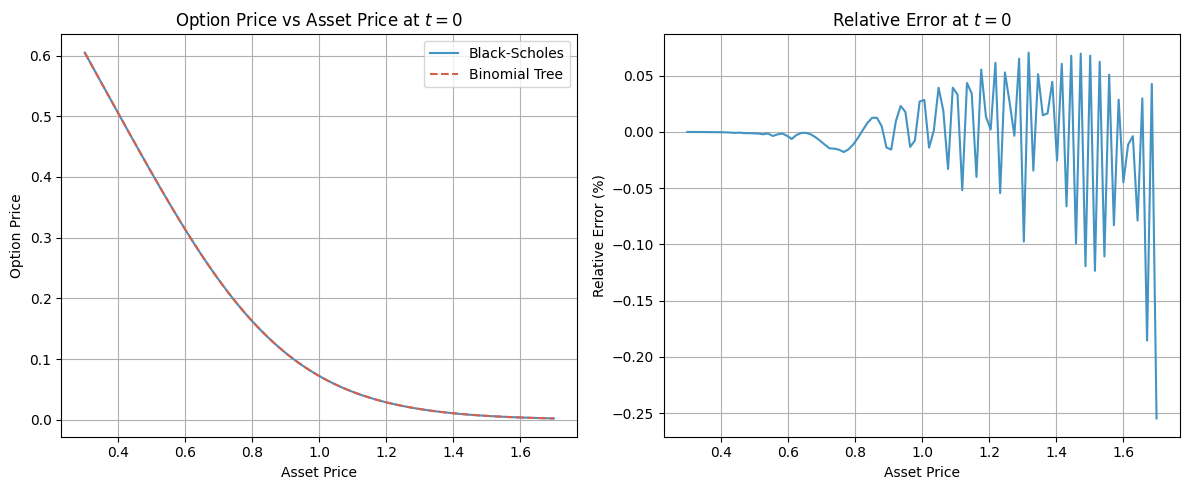

In [4]:
plt.figure(figsize=figsize2)

plt.subplot(1, 2, 1)
plt.plot(Ss, closed_prices, label='Black-Scholes')
plt.plot(Ss, tree_prices, label='Binomial Tree', linestyle='dashed')
plt.xlabel('Asset Price')
plt.ylabel('Option Price')
plt.title(r'Option Price vs Asset Price at $t=0$')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
diff = (tree_prices - closed_prices) / closed_prices
plt.plot(Ss, diff * 100)
plt.xlabel('Asset Price')
plt.ylabel('Relative Error (%)')
plt.title(r'Relative Error at $t=0$')
plt.grid()

plt.tight_layout()

plt.savefig('../../plots/black_scholes/tree_vs_closed.png')
plt.show()

In [5]:
# price near expiry
t = 0.95
closed_prices_near_expiry = closed.price(t, Ss)
tree_prices_near_expiry = tree.predict(t, Ss)

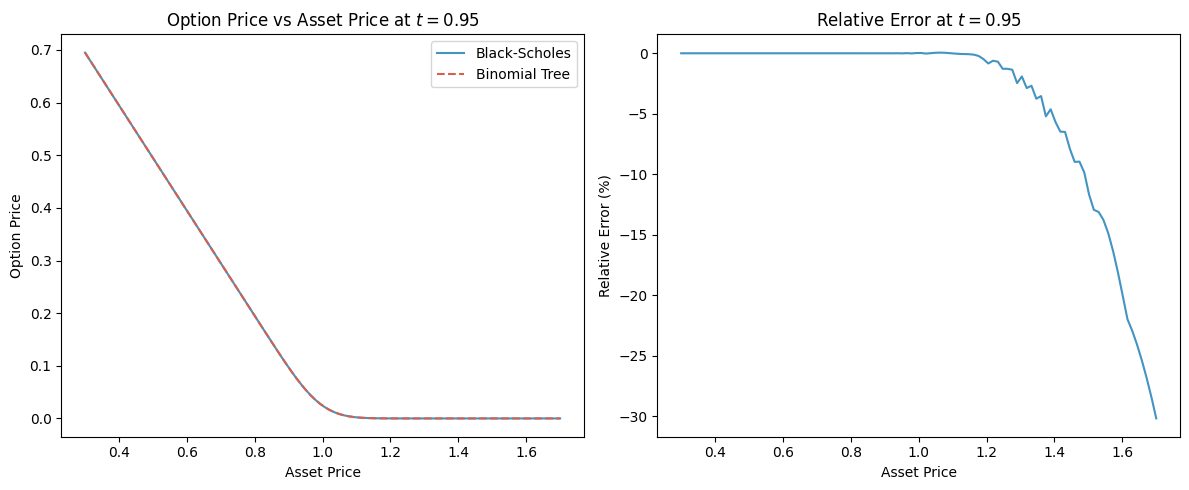

In [6]:
plt.figure(figsize=figsize2)

plt.subplot(1, 2, 1)
plt.plot(Ss, closed_prices_near_expiry, label='Black-Scholes')
plt.plot(Ss, tree_prices_near_expiry, label='Binomial Tree', linestyle='dashed')
plt.xlabel('Asset Price')
plt.ylabel('Option Price')
plt.title(f'Option Price vs Asset Price at $t={t}$')
plt.legend()

plt.subplot(1, 2, 2)
diff = (tree_prices_near_expiry - closed_prices_near_expiry) / closed_prices_near_expiry
plt.plot(Ss, diff * 100)
plt.xlabel('Asset Price')
plt.ylabel('Relative Error (%)')
plt.title(f'Relative Error at $t={t}$')

plt.tight_layout()

# plt.savefig('../../plots/black_scholes/tree_vs_closed.png')
plt.show()

In [7]:
# Term structure
ts = np.linspace(0, T-1e-2, 100)
S = 1.0

closed_prices_ts = closed.price(ts, S)
tree_prices_ts = np.array([tree.predict(t, S) for t in ts]).flatten()

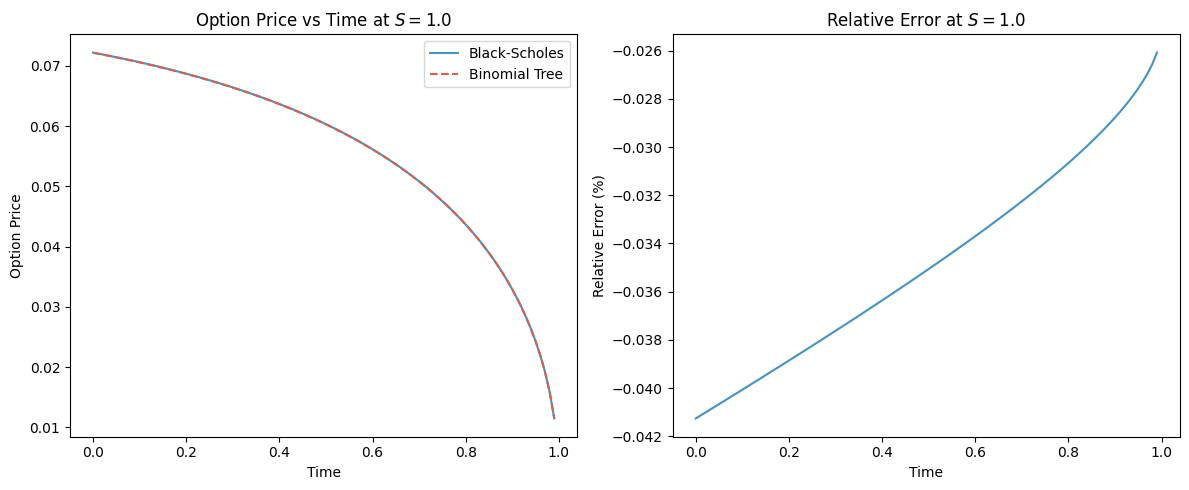

In [8]:
plt.figure(figsize=figsize2)

plt.subplot(1, 2, 1)
plt.plot(ts, closed_prices_ts, label='Black-Scholes')
plt.plot(ts, tree_prices_ts, label='Binomial Tree', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Option Price')
plt.title(f'Option Price vs Time at $S={S}$')
plt.legend()

plt.subplot(1, 2, 2)
diff = (tree_prices_ts - closed_prices_ts) / closed_prices_ts
plt.plot(ts, diff * 100)
plt.xlabel('Time')
plt.ylabel('Relative Error (%)')
plt.title(f'Relative Error at $S={S}$')

plt.tight_layout()

plt.savefig('../../plots/black_scholes/tree_vs_closed_time.png')
plt.show()

In [9]:
# Error f(0, K) vs n_steps
n_steps_list = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
prices_steps = []
errors_steps = []
closed_price = closed.price(0, K)
for n_steps in n_steps_list:
    price, _, _ = binomial_tree(S=K, K=K, r=r, sigma=sigma, T=T, n=n_steps, option_type='put', exercise_type='european')
    prices_steps.append(price)
    error = abs(price - closed_price) / closed_price
    errors_steps.append(error)


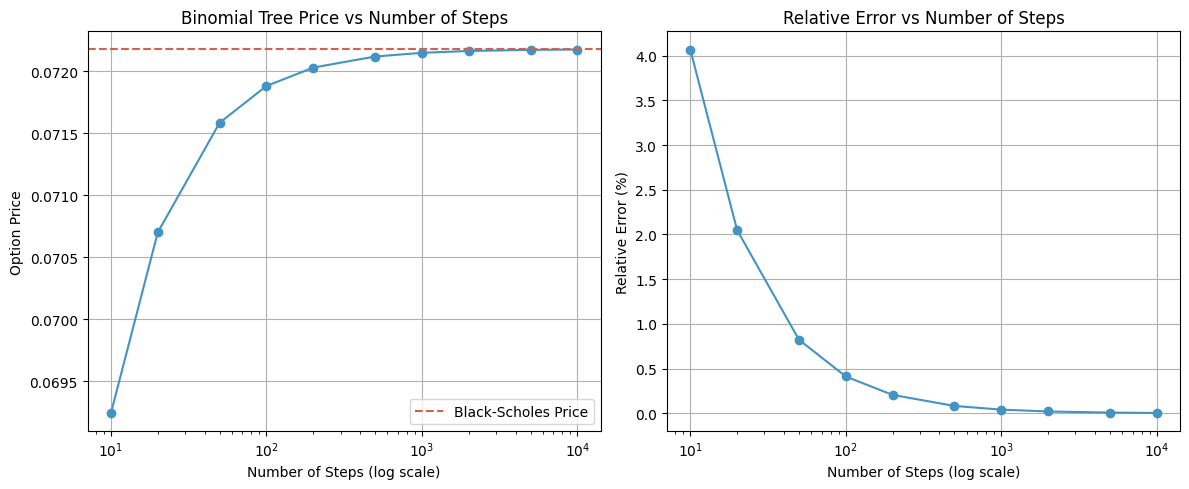

In [10]:
plt.figure(figsize=figsize2)
plt.subplot(1, 2, 1)
plt.plot(n_steps_list, prices_steps, marker='o')
plt.axhline(closed_price, color=CORAL, linestyle='dashed', label='Black-Scholes Price')
plt.xscale('log')
plt.xlabel('Number of Steps (log scale)')
plt.ylabel('Option Price')
plt.title('Binomial Tree Price vs Number of Steps')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(n_steps_list, np.array(errors_steps) * 100, marker='o')
plt.xscale('log')
plt.xlabel('Number of Steps (log scale)')
plt.ylabel('Relative Error (%)')
plt.title('Relative Error vs Number of Steps')
plt.grid()

plt.tight_layout()

plt.savefig('../../plots/black_scholes/tree_convergence.png')
plt.show()